<a href="https://colab.research.google.com/github/kanyijohn/ML-Model-Evaluation-and-Validation/blob/main/Model_Evaluation_%26_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to Trust Your Models
Welcome to one of the most critical modules in your AI engineering journey! Building models is easy—building reliable, trustworthy models is what separates beginners from professionals.

THE DANGER OF RELYING ONLY ON ACCURACY

Dumb Model (always predicts 0) Accuracy: 0.947
Random Forest Accuracy: 0.963

But look at the confusion matrices:


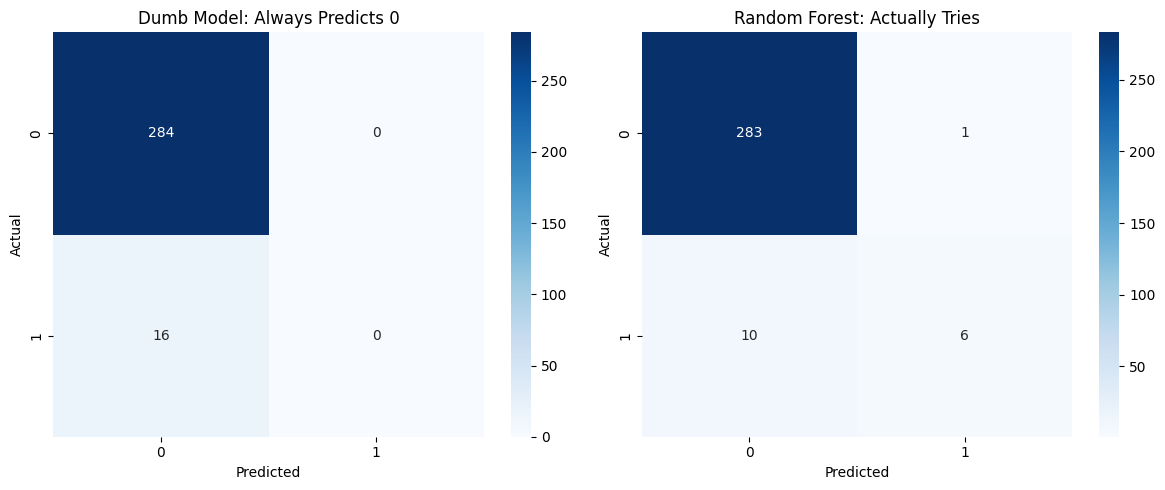

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate an imbalanced dataset to demonstrate
X_imb, y_imb = make_classification(n_samples=1000, n_features=20,
                                    n_classes=2, weights=[0.95, 0.05],
                                    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

# Train a dumb model (always predicts majority class)
class DumbModel:
    def fit(self, X, y):
        self.majority_class = np.argmax(np.bincount(y))

    def predict(self, X):
        return np.full(X.shape[0], self.majority_class)

dumb_model = DumbModel()
dumb_model.fit(X_train, y_train)
y_pred_dumb = dumb_model.predict(X_test)

# Train a real model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Compare
print("="*60)
print("THE DANGER OF RELYING ONLY ON ACCURACY")
print("="*60)

print(f"\nDumb Model (always predicts 0) Accuracy: {accuracy_score(y_test, y_pred_dumb):.3f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

print("\nBut look at the confusion matrices:")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Dumb model confusion matrix
cm_dumb = confusion_matrix(y_test, y_pred_dumb)
sns.heatmap(cm_dumb, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Dumb Model: Always Predicts 0')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Random Forest: Actually Tries')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

📊 The Four Key Classification Metrics

In [2]:
# Calculate all metrics for both models
def print_metrics(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred, zero_division=0):.3f}")

    # Detailed classification report
    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

print_metrics(y_test, y_pred_dumb, "DUMB MODEL (Always 0)")
print_metrics(y_test, y_pred_rf, "RANDOM FOREST")


DUMB MODEL (Always 0)
----------------------------------------
Accuracy:  0.947
Precision: 0.000
Recall:    0.000
F1-Score:  0.000

Detailed Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       284
           1       0.00      0.00      0.00        16

    accuracy                           0.95       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.90      0.95      0.92       300


RANDOM FOREST
----------------------------------------
Accuracy:  0.963
Precision: 0.857
Recall:    0.375
F1-Score:  0.522

Detailed Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       284
           1       0.86      0.38      0.52        16

    accuracy                           0.96       300
   macro avg       0.91      0.69      0.75       300
weighted avg       0.96      0.96      0.96       300



📈 ROC Curves and AUC

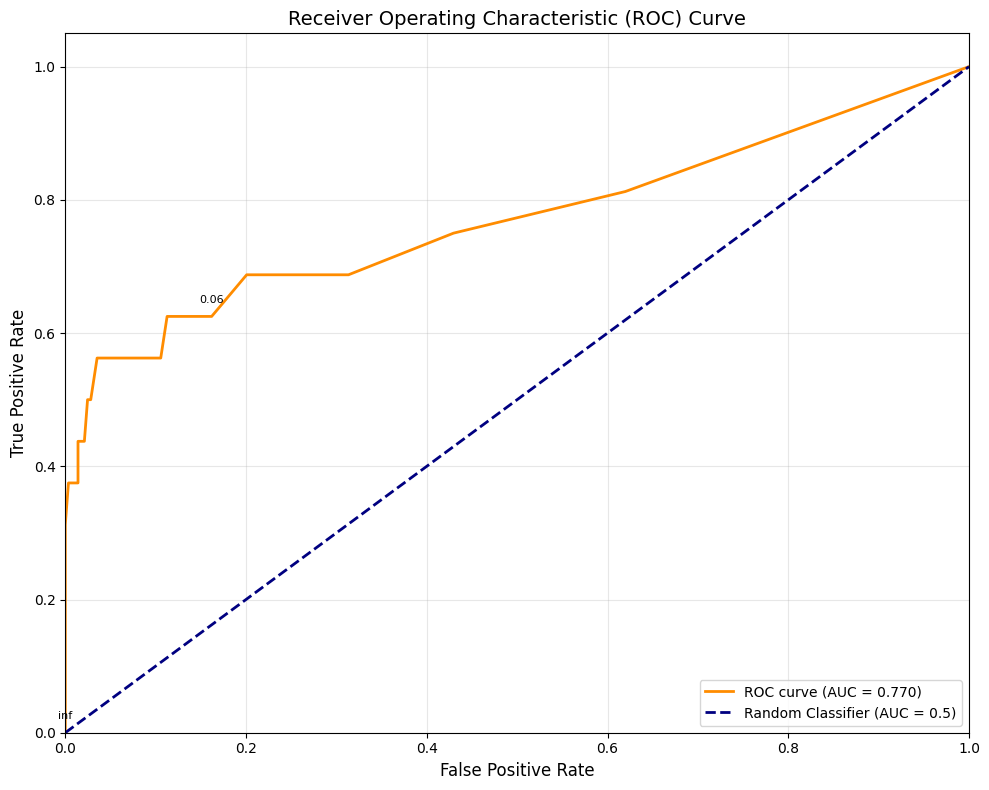


Optimal threshold (maximizing tpr - fpr): 0.180
At this threshold:
  True Positive Rate: 0.562
  False Positive Rate: 0.035


In [3]:
# Get prediction probabilities
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Add threshold annotations
for i, threshold in enumerate(thresholds[::20]):  # Show every 20th threshold
    plt.annotate(f'{threshold:.2f}',
                (fpr[i*20], tpr[i*20]),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                fontsize=8)

plt.tight_layout()
plt.show()

# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold (maximizing tpr - fpr): {optimal_threshold:.3f}")
print(f"At this threshold:")
print(f"  True Positive Rate: {tpr[optimal_idx]:.3f}")
print(f"  False Positive Rate: {fpr[optimal_idx]:.3f}")

🎯 Precision-Recall Curves (Better for Imbalanced Data)

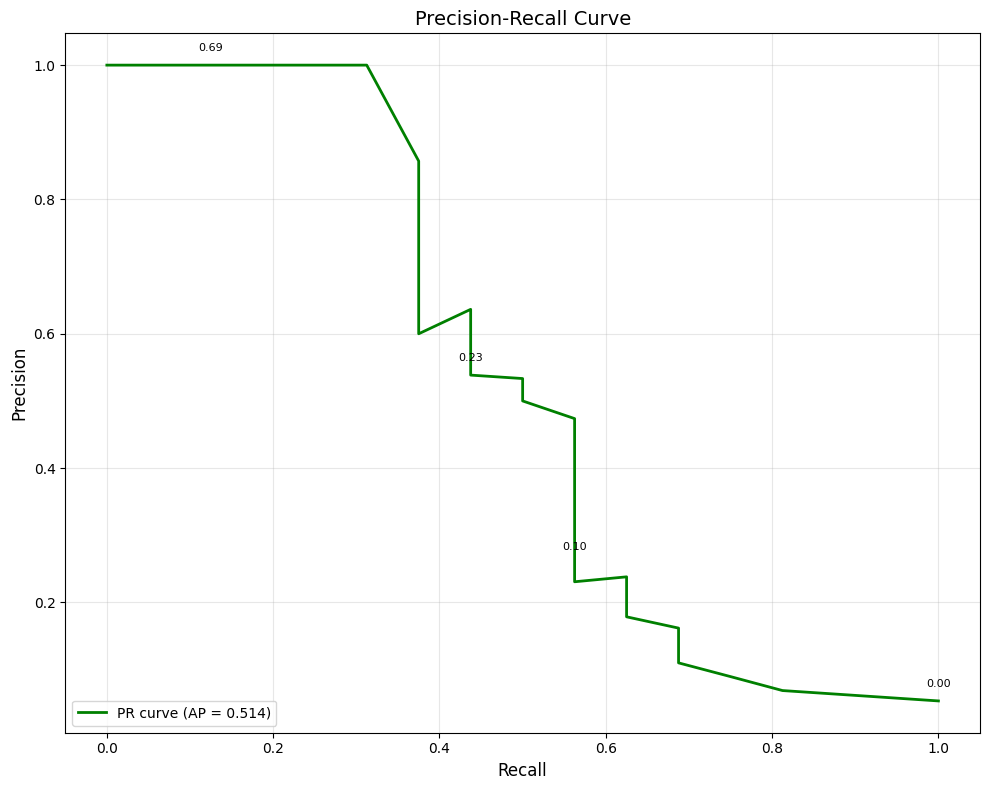

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba_rf)
avg_precision = average_precision_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='green', lw=2,
         label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# Add threshold annotations
for i, threshold in enumerate(pr_thresholds[::10]):  # Show every 10th threshold
    if i < len(recall)-1:
        plt.annotate(f'{threshold:.2f}',
                    (recall[i*10], precision[i*10]),
                    textcoords="offset points",
                    xytext=(0,10),
                    ha='center',
                    fontsize=8)

plt.tight_layout()
plt.show()

# PART 2: REGRESSION METRICS
## 📐 Understanding Error Metrics

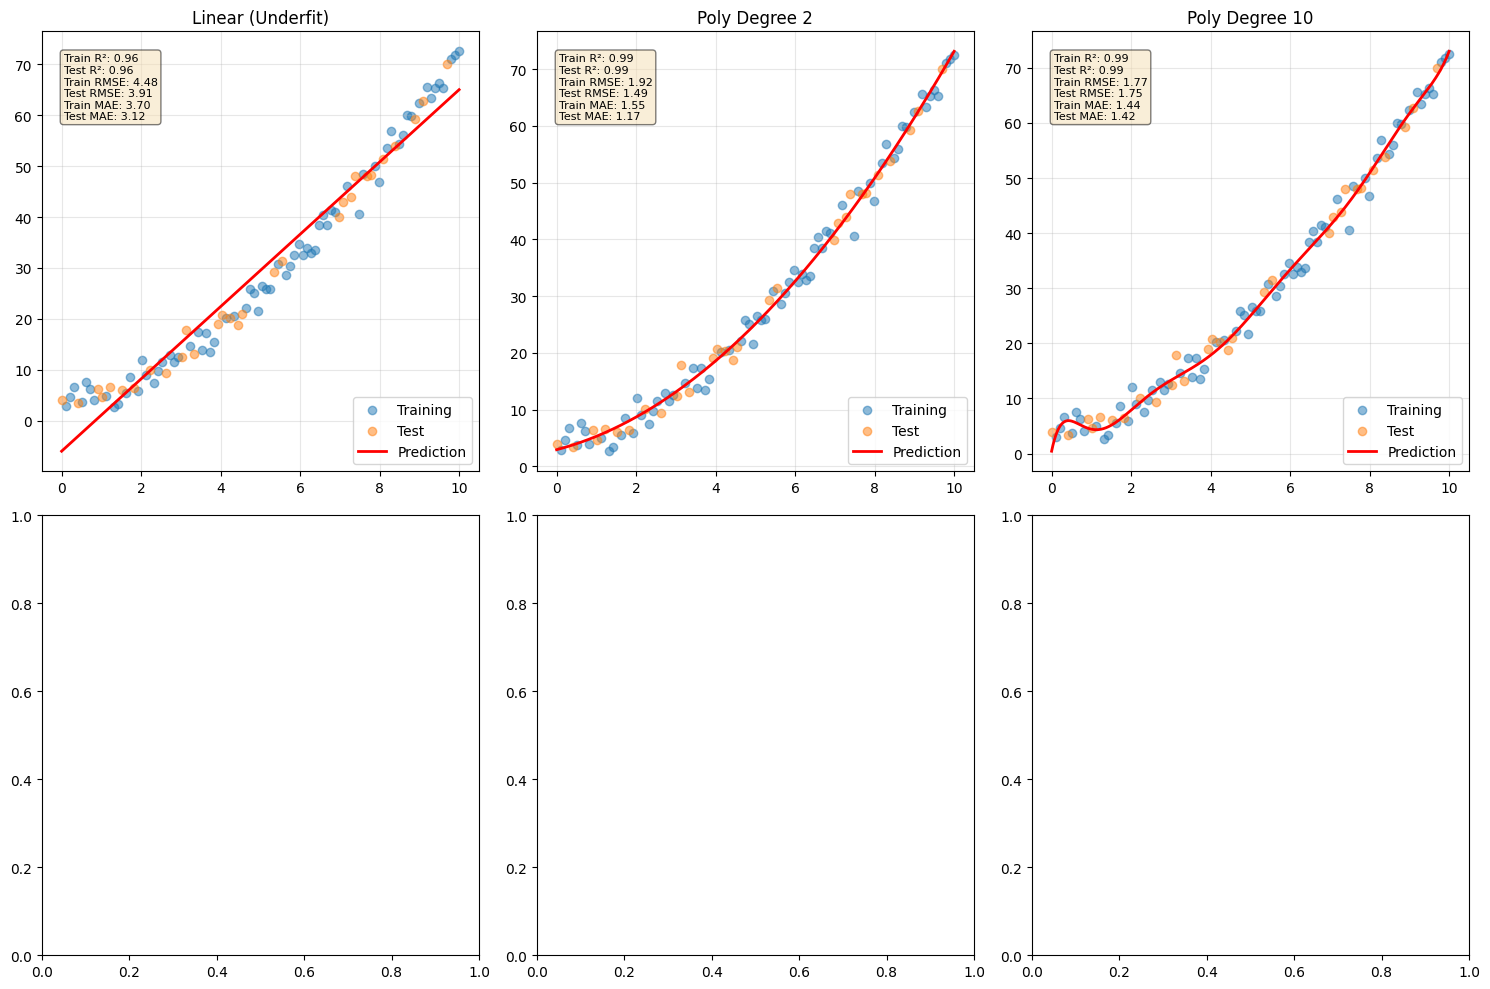

REGRESSION METRICS EXPLAINED

R² (Coefficient of Determination):
  • Proportion of variance explained by the model
  • Range: 0 to 1 (higher is better)
  • 1.0 means perfect prediction
  • 0.0 means no better than predicting the mean

RMSE (Root Mean Square Error):
  • Average prediction error in same units as target
  • Penalizes large errors more heavily
  • More sensitive to outliers than MAE

MAE (Mean Absolute Error):
  • Average absolute error in same units as target
  • Less sensitive to outliers than RMSE
  • More interpretable for business users



In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline # Added this import

# Generate non-linear data
np.random.seed(42)
X_reg = np.linspace(0, 10, 100).reshape(-1, 1)
y_reg = 2 * X_reg.ravel() + 3 + np.random.randn(100) * 2

# Add a quadratic component for realism
y_reg = y_reg + 0.5 * X_reg.ravel()**2

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Train different models
models = {
    'Linear (Underfit)': LinearRegression(),
    'Poly Degree 2': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    'Poly Degree 10': Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('linear', LinearRegression())
    ])
}

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
X_plot = np.linspace(0, 10, 300).reshape(-1, 1)

for idx, (name, model) in enumerate(models.items()):
    row = idx // 3
    col = idx % 3

    # Train model
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_plot)

    # Plot data and predictions
    axes[row, col].scatter(X_train_reg, y_train_reg, alpha=0.5, label='Training')
    axes[row, col].scatter(X_test_reg, y_test_reg, alpha=0.5, label='Test')
    axes[row, col].plot(X_plot, y_pred, 'r-', linewidth=2, label='Prediction')
    axes[row, col].set_title(name)
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

    # Calculate metrics
    y_train_pred = model.predict(X_train_reg)
    y_test_pred = model.predict(X_test_reg)

    metrics = {
        'Train R²': r2_score(y_train_reg, y_train_pred),
        'Test R²': r2_score(y_test_reg, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_reg, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_reg, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train_reg, y_train_pred),
        'Test MAE': mean_absolute_error(y_test_reg, y_test_pred)
    }

    # Display metrics
    textstr = '\n'.join([f'{k}: {v:.2f}' for k, v in metrics.items()])
    axes[row, col].text(0.05, 0.95, textstr, transform=axes[row, col].transAxes,
                       fontsize=8, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Explain the metrics
print("="*60)
print("REGRESSION METRICS EXPLAINED")
print("="*60)
print("""
R² (Coefficient of Determination):
  • Proportion of variance explained by the model
  • Range: 0 to 1 (higher is better)
  • 1.0 means perfect prediction
  • 0.0 means no better than predicting the mean

RMSE (Root Mean Square Error):
  • Average prediction error in same units as target
  • Penalizes large errors more heavily
  • More sensitive to outliers than MAE

MAE (Mean Absolute Error):
  • Average absolute error in same units as target
  • Less sensitive to outliers than RMSE
  • More interpretable for business users
""")

Adjusted R²

,Model,R2_Train,R2_Test,Adj_R2_Train,Adj_R2_Test,RMSE_Train,RMSE_Test,MAE_Train,MAE_Test
0,Linear (Underfit),0.955515,0.962362,0.954861,0.961018,4.476325,3.905289,3.697249,3.120743
1,Poly Degree 2,0.991810,0.994501,0.991438,0.993866,1.920648,1.492747,1.547900,1.170750
2,Poly Degree 10,0.993049,0.992449,0.991731,0.987835,1.769406,1.749190,1.438746,1.418533


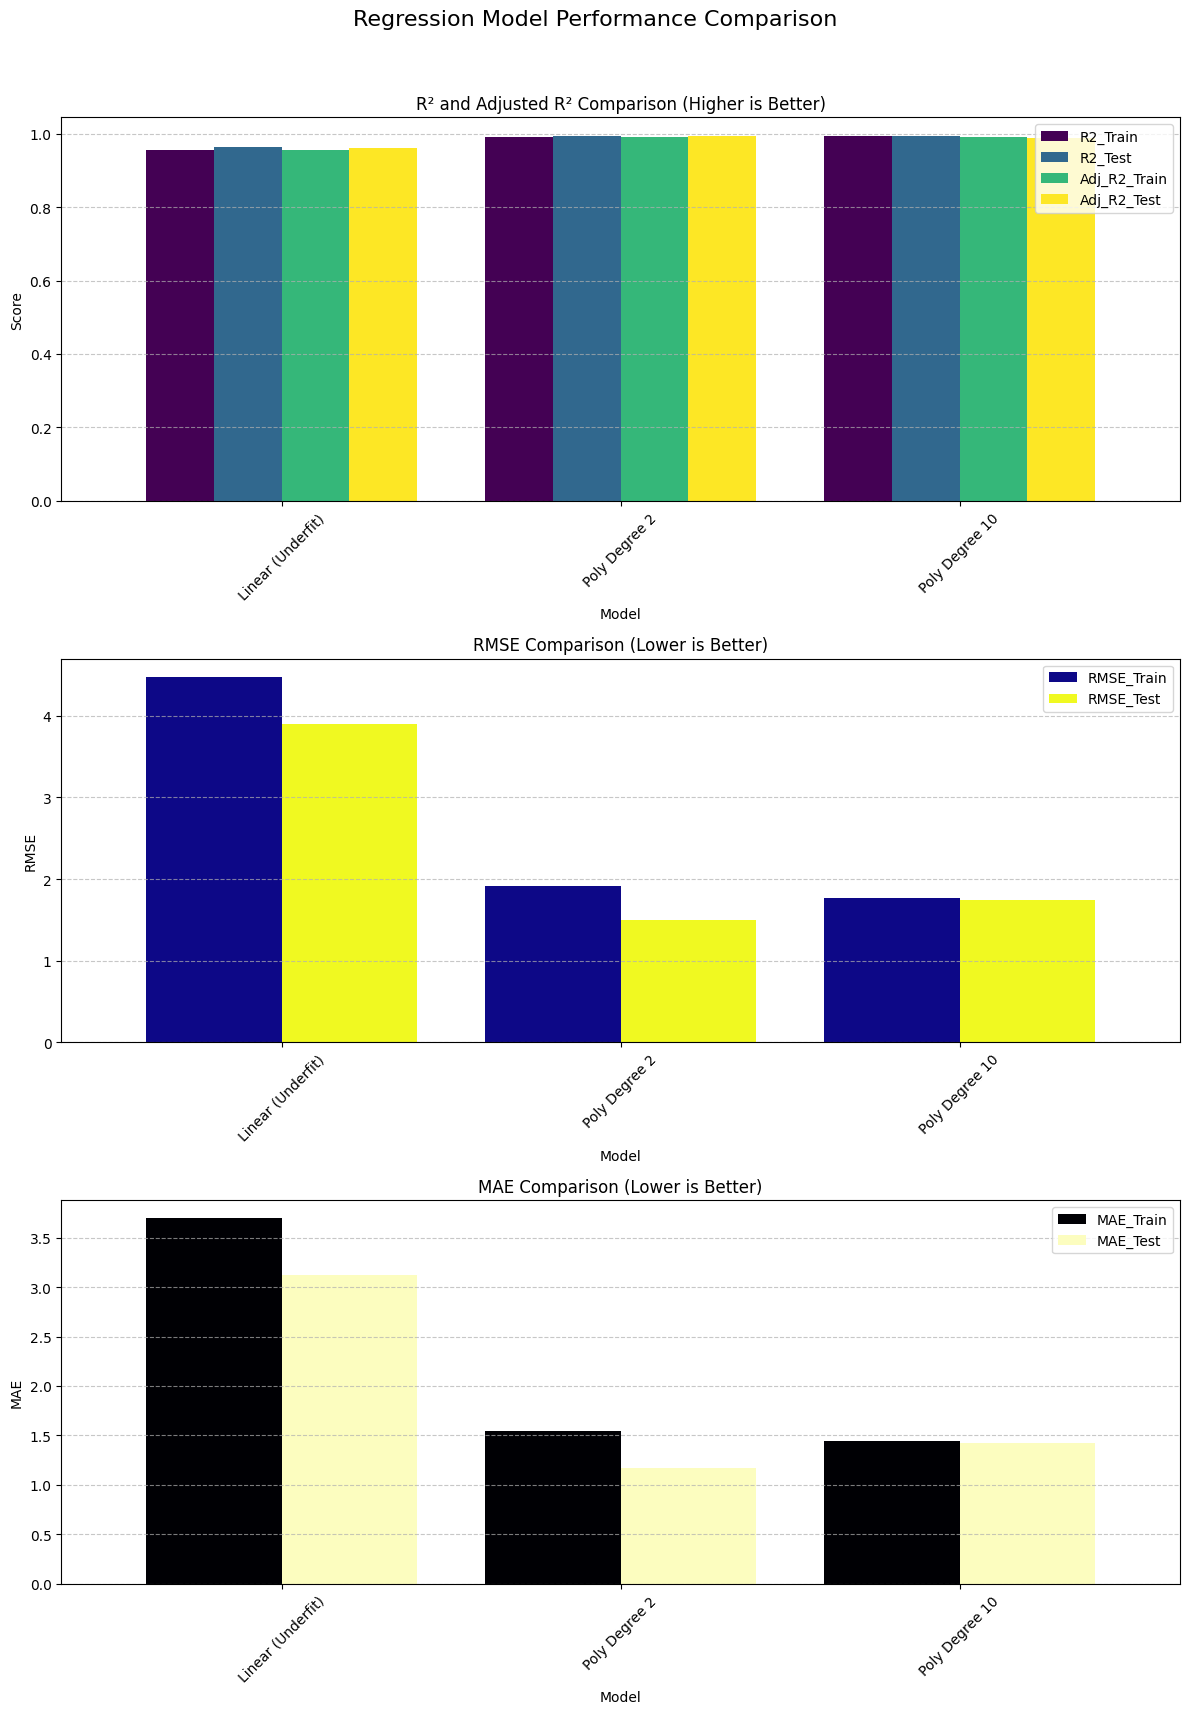

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np

# Ensure numpy is imported for np.sqrt (already covered by previous cells but good practice)

all_model_metrics = []

for name, model in models.items():
    model.fit(X_train_reg, y_train_reg)

    y_train_pred = model.predict(X_train_reg)
    y_test_pred = model.predict(X_test_reg)

    # R-squared
    r2_train = r2_score(y_train_reg, y_train_pred)
    r2_test = r2_score(y_test_reg, y_test_pred)

    # Adjusted R-squared calculation: 1 - (1-R^2)*(n-1)/(n-p-1)
    n_train = X_train_reg.shape[0]
    n_test = X_test_reg.shape[0]

    # Determine number of features 'p' (number of independent variables, excluding intercept)
    # For pipelines with PolynomialFeatures, p is the number of coefficients of the LinearRegression step
    if 'Poly' in name:
        # Access the linear regression step in the pipeline
        p_train = model.named_steps['linear'].coef_.shape[0]
        p_test = p_train # Number of features is constant for the model
    else: # For a standalone LinearRegression model
        p_train = model.coef_.shape[0]
        p_test = p_train

    # Handle cases where n - p - 1 might be non-positive
    adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_train - 1) if (n_train - p_train - 1) > 0 else np.nan
    adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_test - 1) if (n_test - p_test - 1) > 0 else np.nan

    # RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))

    # MAE
    mae_train = mean_absolute_error(y_train_reg, y_train_pred)
    mae_test = mean_absolute_error(y_test_reg, y_test_pred)

    all_model_metrics.append({
        'Model': name,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'Adj_R2_Train': adj_r2_train,
        'Adj_R2_Test': adj_r2_test,
        'RMSE_Train': rmse_train,
        'RMSE_Test': rmse_test,
        'MAE_Train': mae_train,
        'MAE_Test': mae_test
    })

metrics_df = pd.DataFrame(all_model_metrics)
display(metrics_df)

# --- Visualization of Metrics ---
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Regression Model Performance Comparison', fontsize=16)

# Plot R2 and Adjusted R2
metrics_df_r2_adj = metrics_df[['Model', 'R2_Train', 'R2_Test', 'Adj_R2_Train', 'Adj_R2_Test']].set_index('Model')
metrics_df_r2_adj.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.8)
axes[0].set_title('R² and Adjusted R² Comparison (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSE
metrics_df_rmse = metrics_df[['Model', 'RMSE_Train', 'RMSE_Test']].set_index('Model')
metrics_df_rmse.plot(kind='bar', ax=axes[1], colormap='plasma', width=0.8)
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot MAE
metrics_df_mae = metrics_df[['Model', 'MAE_Train', 'MAE_Test']].set_index('Model')
metrics_df_mae.plot(kind='bar', ax=axes[2], colormap='magma', width=0.8)
axes[2].set_title('MAE Comparison (Lower is Better)')
axes[2].set_ylabel('MAE')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent titles from overlapping
plt.show()

# PART 3: CROSS-VALIDATION TECHNIQUES

Why Cross-Validation?

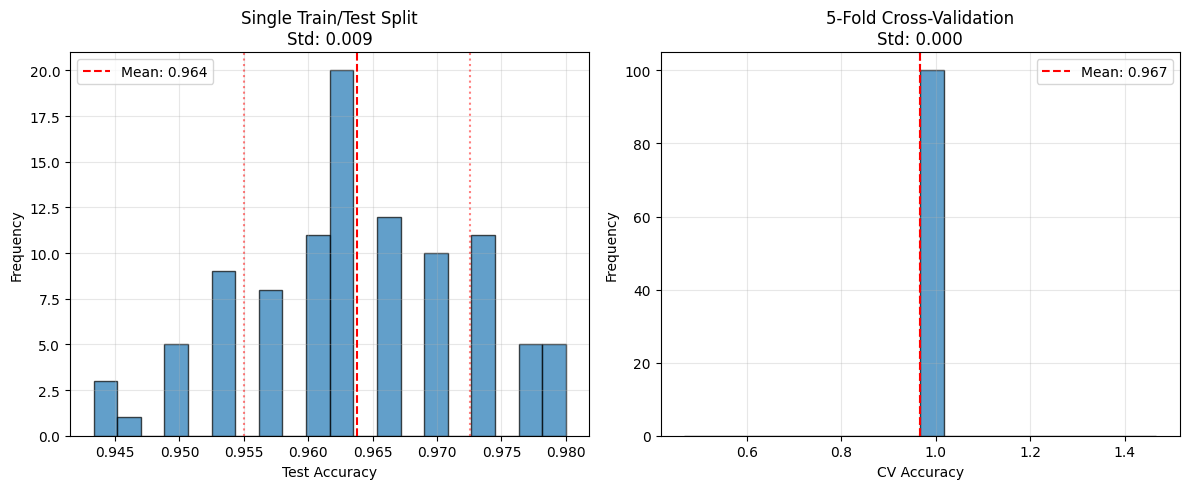

Cross-validation gives MORE RELIABLE and LESS VARIABLE estimates!


In [7]:
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, cross_val_score

# Demonstrate the problem with single train/test split
n_experiments = 100
scores_single_split = []
scores_cv = []

for i in range(n_experiments):
    # Different random splits each time
    X_train, X_test, y_train, y_test = train_test_split(
        X_imb, y_imb, test_size=0.3, random_state=i
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    scores_single_split.append(model.score(X_test, y_test))

    # 5-fold CV on full data
    cv_scores = cross_val_score(model, X_imb, y_imb, cv=5)
    scores_cv.append(np.mean(cv_scores))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(scores_single_split, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(np.mean(scores_single_split), color='red', linestyle='--',
            label=f'Mean: {np.mean(scores_single_split):.3f}')
plt.axvline(np.mean(scores_single_split) + np.std(scores_single_split),
            color='red', linestyle=':', alpha=0.5)
plt.axvline(np.mean(scores_single_split) - np.std(scores_single_split),
            color='red', linestyle=':', alpha=0.5)
plt.xlabel('Test Accuracy')
plt.ylabel('Frequency')
plt.title(f'Single Train/Test Split\nStd: {np.std(scores_single_split):.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(scores_cv, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(np.mean(scores_cv), color='red', linestyle='--',
            label=f'Mean: {np.mean(scores_cv):.3f}')
plt.axvline(np.mean(scores_cv) + np.std(scores_cv),
            color='red', linestyle=':', alpha=0.5)
plt.axvline(np.mean(scores_cv) - np.std(scores_cv),
            color='red', linestyle=':', alpha=0.5)
plt.xlabel('CV Accuracy')
plt.ylabel('Frequency')
plt.title(f'5-Fold Cross-Validation\nStd: {np.std(scores_cv):.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Cross-validation gives MORE RELIABLE and LESS VARIABLE estimates!")

Types of Cross-Validation

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(


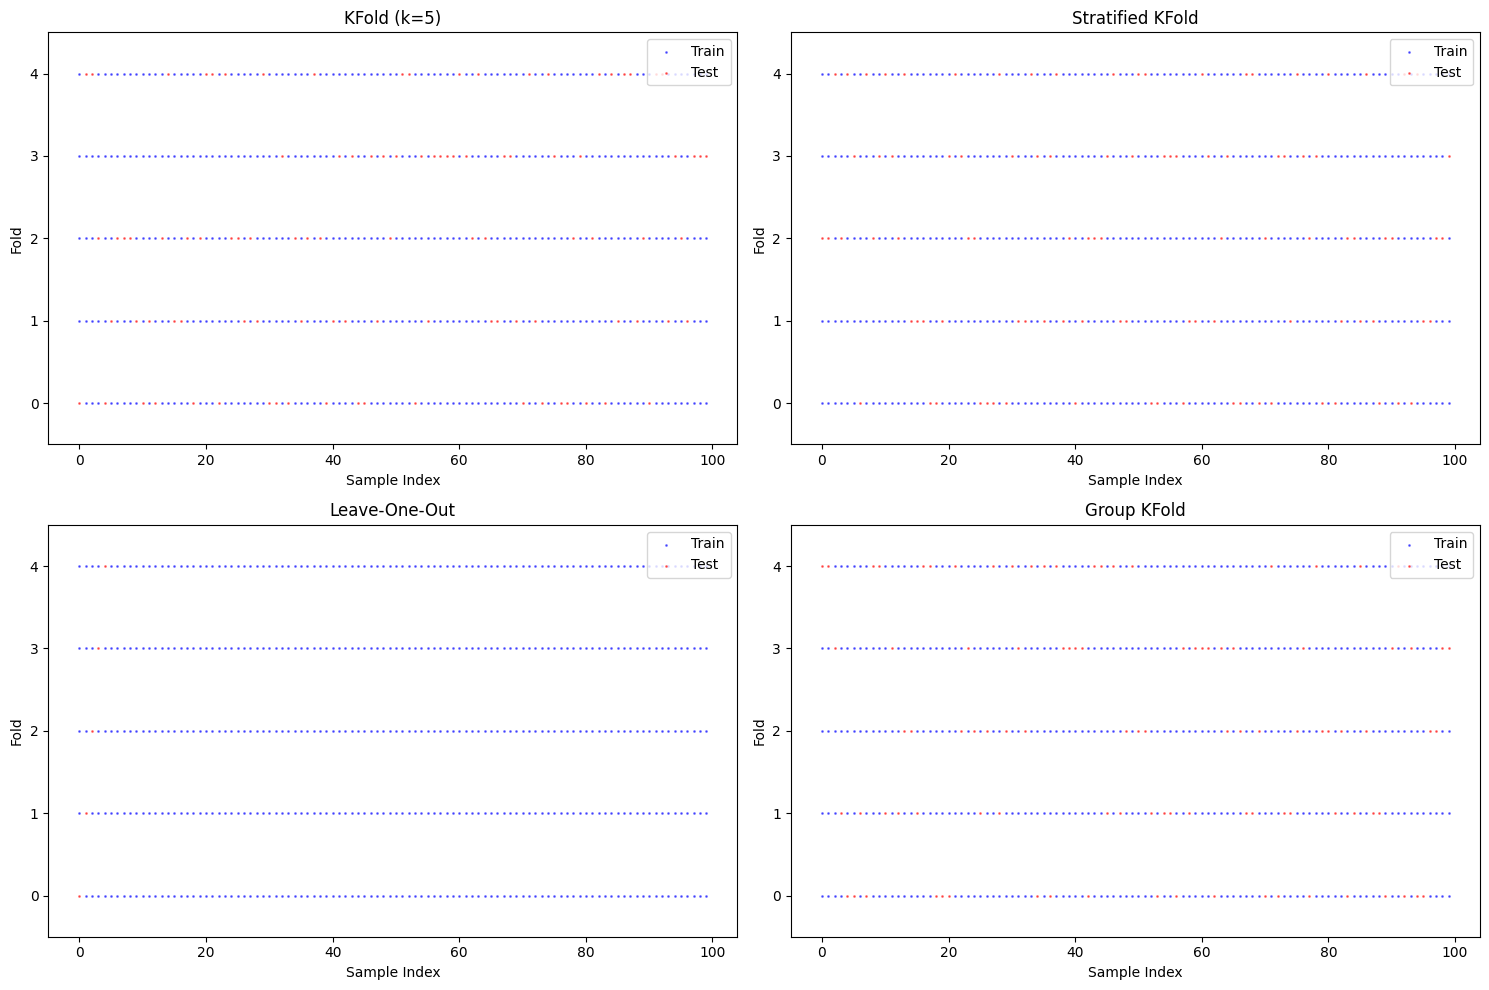

In [8]:
# Demonstrate different CV strategies
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit

# Create sample data
X_demo = np.arange(100).reshape(-1, 1)
y_demo = np.random.randint(0, 2, 100)
groups = np.random.randint(0, 10, 100)  # For grouped CV

# Different CV strategies
cv_strategies = {
    'KFold (k=5)': KFold(n_splits=5, shuffle=True, random_state=42),
    'Stratified KFold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'Leave-One-Out': LeaveOneOut(),
    'Group KFold': GroupKFold(n_splits=5)
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, (name, cv) in enumerate(cv_strategies.items()):
    row = idx // 2
    col = idx % 2

    # Plot the splits
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_demo, y_demo, groups)):
        axes[row, col].scatter(train_idx, [fold] * len(train_idx),
                              c='blue', s=1, alpha=0.5, label='Train' if fold == 0 else '')
        axes[row, col].scatter(test_idx, [fold] * len(test_idx),
                              c='red', s=1, alpha=0.5, label='Test' if fold == 0 else '')

    axes[row, col].set_xlabel('Sample Index')
    axes[row, col].set_ylabel('Fold')
    axes[row, col].set_title(name)
    axes[row, col].legend(['Train', 'Test'])
    axes[row, col].set_ylim(-0.5, 4.5)

plt.tight_layout()
plt.show()

# PART 4: LEARNING CURVES AND DIAGNOSTICS

Detecting Bias vs Variance

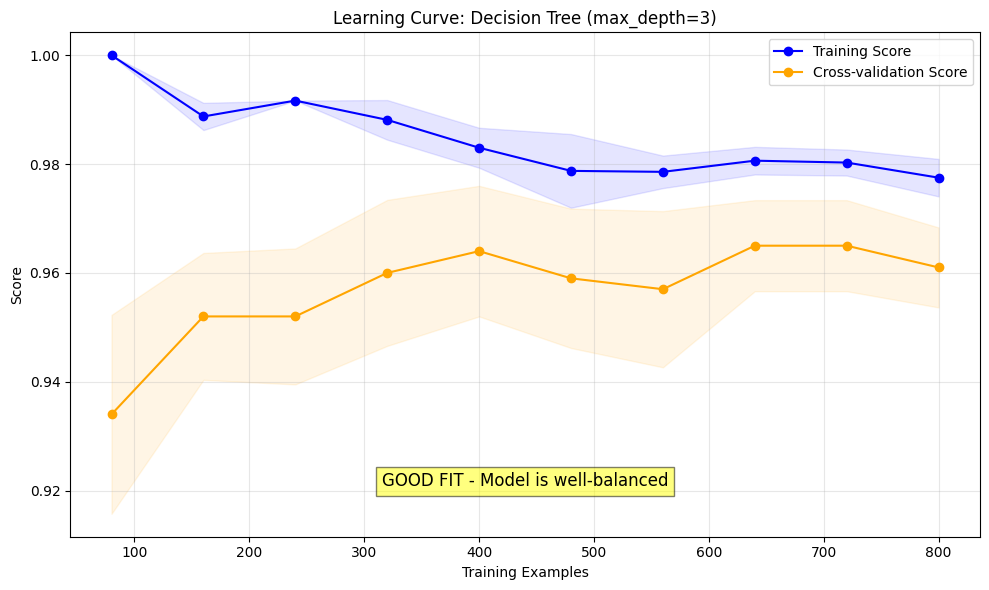

Decision Tree (max_depth=3): GOOD FIT - Model is well-balanced



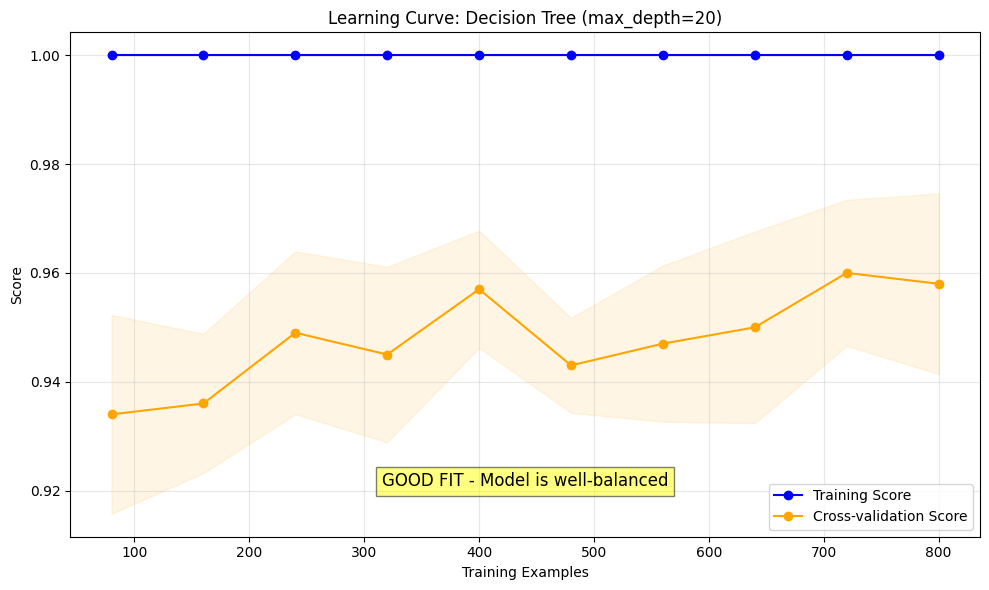

Decision Tree (max_depth=20): GOOD FIT - Model is well-balanced



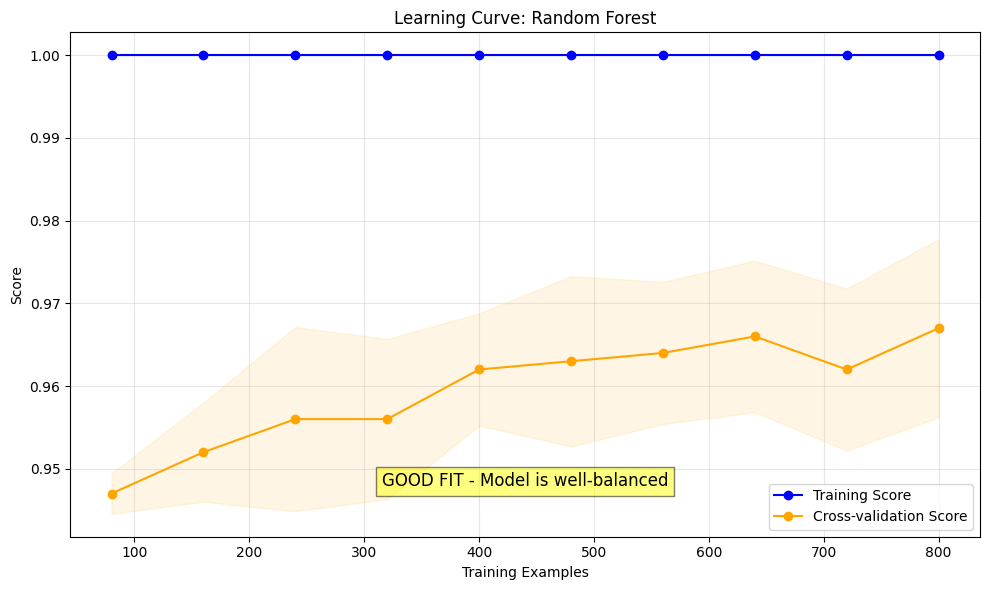

Random Forest: GOOD FIT - Model is well-balanced



In [9]:
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier # Added import for DecisionTreeClassifier

def plot_learning_curve(estimator, X, y, title):
    """Plot learning curve to diagnose bias/variance"""

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                     alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation Score')

    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.title(f'Learning Curve: {title}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    # Add diagnosis
    gap = train_mean[-1] - test_mean[-1]
    if gap > 0.1:
        diagnosis = "HIGH VARIANCE (overfitting) - Add more data or reduce complexity"
    elif train_mean[-1] < 0.7:
        diagnosis = "HIGH BIAS (underfitting) - Increase model complexity"
    else:
        diagnosis = "GOOD FIT - Model is well-balanced"

    plt.text(0.5, 0.1, diagnosis, transform=plt.gca().transAxes,
             ha='center', fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))

    plt.tight_layout()
    plt.show()

    return diagnosis

# Compare different models
models_to_diagnose = {
    'Decision Tree (max_depth=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Decision Tree (max_depth=20)': DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models_to_diagnose.items():
    diagnosis = plot_learning_curve(model, X_imb, y_imb, name)
    print(f"{name}: {diagnosis}\n")

Validation Curves for Hyperparameter Tuning

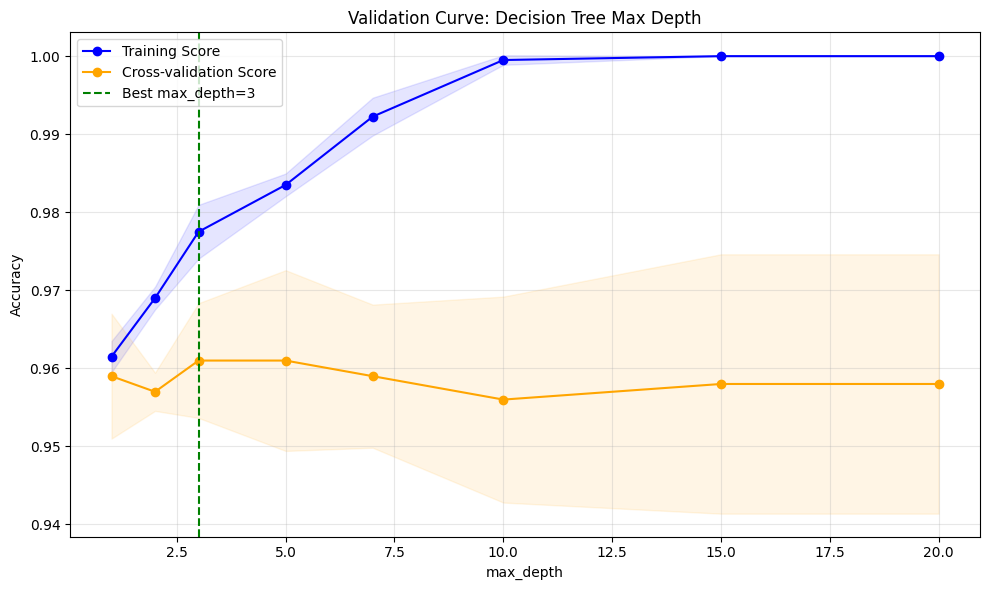

Optimal max_depth: 3


In [10]:
from sklearn.model_selection import validation_curve

def plot_validation_curve(estimator, X, y, param_name, param_range, title):
    """Plot validation curve to find optimal hyperparameter"""

    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=5, scoring='accuracy', n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color='blue')
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                     alpha=0.1, color='orange')
    plt.plot(param_range, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(param_range, test_mean, 'o-', color='orange', label='Cross-validation Score')

    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.title(f'Validation Curve: {title}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    # Find best parameter
    best_param = param_range[np.argmax(test_mean)]
    plt.axvline(x=best_param, color='green', linestyle='--',
                label=f'Best {param_name}={best_param}')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return best_param

# Example: Tuning max_depth for Decision Tree
param_range = [1, 2, 3, 5, 7, 10, 15, 20]
best_depth = plot_validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_imb, y_imb,
    param_name='max_depth',
    param_range=param_range,
    title='Decision Tree Max Depth'
)
print(f"Optimal max_depth: {best_depth}")

# PART 5: HYPERPARAMETER TUNING

GridSearchCV: Exhaustive Search

Fitting 5 folds for each of 32 candidates, totalling 160 fits
GRID SEARCH RESULTS
Best parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}
Best CV accuracy: 0.947
Test accuracy: 0.960


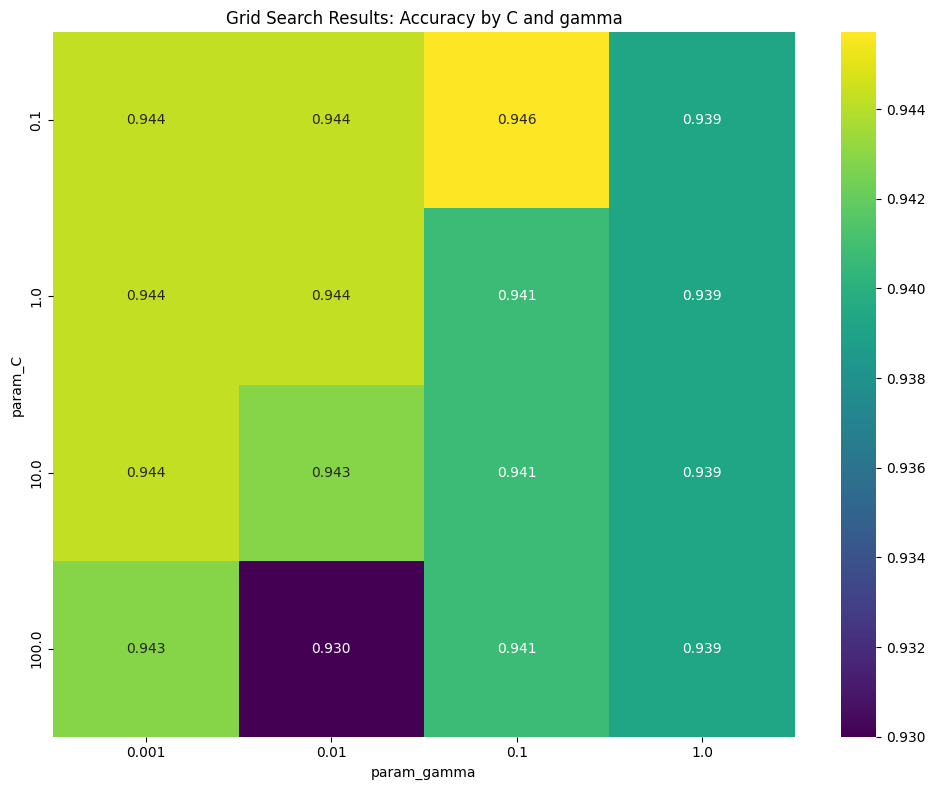

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

# Create grid search
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

print("="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")
print(f"Test accuracy: {grid_search.score(X_test, y_test):.3f}")

# Visualize grid search results
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis')
plt.title('Grid Search Results: Accuracy by C and gamma')
plt.tight_layout()
plt.show()

RandomizedSearchCV: Efficient Search

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define parameter distributions
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Create random search
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,  # Try 50 random combinations
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit random search
random_search.fit(X_train, y_train)

print("="*60)
print("RANDOM SEARCH RESULTS")
print("="*60)
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.3f}")
print(f"Test accuracy: {random_search.score(X_test, y_test):.3f}")

# Compare Grid vs Random
print("\nGrid Search: Explored", len(param_grid_svm['C']) * len(param_grid_svm['gamma']) * 2, "combinations")
print("Random Search: Explored 50 combinations (more efficient for high dimensions!)")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
RANDOM SEARCH RESULTS
Best parameters: {'max_depth': 19, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 179}
Best CV accuracy: 0.963
Test accuracy: 0.973

Grid Search: Explored 32 combinations
Random Search: Explored 50 combinations (more efficient for high dimensions!)


### Explanation of Cell `zZTKciW1BGJP`: GridSearchCV

This cell demonstrates **GridSearchCV**, a method for hyperparameter tuning that exhaustively searches through a specified subset of hyperparameters.

```python
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
```
*   `from sklearn.model_selection import GridSearchCV`: Imports the `GridSearchCV` class from scikit-learn, which performs an exhaustive search over specified parameter values for an estimator.
*   `from sklearn.svm import SVC`: Imports the `SVC` (Support Vector Classifier) class, which is the machine learning model we will be tuning.

```python
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}
```
*   `param_grid_svm`: This dictionary defines the **hyperparameter grid**. `GridSearchCV` will try every possible combination of these values for the `C`, `gamma`, and `kernel` parameters of the `SVC` model.
    *   `'C'`: Regularization parameter. Smaller values specify stronger regularization.
    *   `'gamma'`: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    *   `'kernel'`: Specifies the kernel type to be used in the algorithm.

```python
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
```
*   `grid_search = GridSearchCV(...)`: Initializes the `GridSearchCV` object.
    *   `SVC(random_state=42)`: The estimator (model) to tune. `random_state` ensures reproducibility.
    *   `param_grid_svm`: The dictionary defining the hyperparameter grid to search.
    *   `cv=5`: Specifies 5-fold cross-validation. The training data will be split into 5 parts, and the model will be trained and evaluated 5 times, each time using a different fold as the validation set.
    *   `scoring='accuracy'`: The metric used to evaluate the model's performance during cross-validation.
    *   `n_jobs=-1`: Uses all available CPU cores for parallel processing, speeding up the search.
    *   `verbose=1`: Controls the verbosity: higher values print more messages during the search.

```python
grid_search.fit(X_train, y_train)
```
*   `grid_search.fit(X_train, y_train)`: Executes the grid search. It trains and evaluates the `SVC` model for every combination of hyperparameters defined in `param_grid_svm` using the `X_train` and `y_train` data, performing 5-fold cross-validation for each combination.

```python
print("=

# PART 6: DATA LEAKAGE - THE SILENT KILLER

What is Data Leakage?

Data leakage occurs when information from outside the training dataset is used to create the model, leading to overly optimistic performance.

In [13]:
# Demonstrate data leakage
from sklearn.feature_selection import SelectKBest, f_classif

# Create dataset with leakage example
np.random.seed(42)
n_samples = 1000
n_features = 100

X_leak = np.random.randn(n_samples, n_features)
y_leak = (X_leak[:, 0] + X_leak[:, 1] > 0).astype(int)  # Only first 2 features matter

# Split data (correct way)
X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3, random_state=42)

# LEAKY approach: Feature selection on FULL dataset before splitting
selector_leaky = SelectKBest(f_classif, k=10)
X_selected_leaky = selector_leaky.fit_transform(X_leak, y_leak)  # LEAKAGE!
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_selected_leaky, y_leak, test_size=0.3, random_state=42
)

# CORRECT approach: Feature selection ONLY on training data
selector_correct = SelectKBest(f_classif, k=10)
X_train_selected = selector_correct.fit_transform(X_train, y_train)
X_test_selected = selector_correct.transform(X_test)

# Train models
model_leaky = RandomForestClassifier(random_state=42)
model_leaky.fit(X_train_leaky, y_train_leaky)

model_correct = RandomForestClassifier(random_state=42)
model_correct.fit(X_train_selected, y_train)

# Compare
print("="*60)
print("DATA LEAKAGE DEMONSTRATION")
print("="*60)
print(f"Leaky model - Train accuracy: {model_leaky.score(X_train_leaky, y_train_leaky):.3f}")
print(f"Leaky model - Test accuracy: {model_leaky.score(X_test_leaky, y_test_leaky):.3f}")
print(f"\nCorrect model - Train accuracy: {model_correct.score(X_train_selected, y_train):.3f}")
print(f"Correct model - Test accuracy: {model_correct.score(X_test_selected, y_test):.3f}")

# Notice how leaky model's test accuracy is suspiciously high?
# That's because the feature selection "peeked" at the test data!

DATA LEAKAGE DEMONSTRATION
Leaky model - Train accuracy: 1.000
Leaky model - Test accuracy: 0.977

Correct model - Train accuracy: 1.000
Correct model - Test accuracy: 0.963


Common Sources of Data Leakage

In [14]:
# Example 1: Scaling before splitting (LEAKY!)
from sklearn.preprocessing import StandardScaler

# LEAKY scaling
scaler_leaky = StandardScaler()
X_scaled_leaky = scaler_leaky.fit_transform(X_leak)  # Uses test data statistics!
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled_leaky, y_leak, test_size=0.3, random_state=42
)

# CORRECT scaling
X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3, random_state=42)
scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train)
X_test_scaled = scaler_correct.transform(X_test)

# Example 2: Handling missing values before splitting
from sklearn.impute import SimpleImputer

# LEAKY imputation
imputer_leaky = SimpleImputer(strategy='mean')
X_imputed_leaky = imputer_leaky.fit_transform(X_leak)  # Uses test data mean!
X_train, X_test, y_train, y_test = train_test_split(X_imputed_leaky, y_leak, test_size=0.3)

# CORRECT imputation
X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3)
imputer_correct = SimpleImputer(strategy='mean')
X_train_imputed = imputer_correct.fit_transform(X_train)
X_test_imputed = imputer_correct.transform(X_test)

print("\n🔴 ALWAYS fit preprocessing on TRAINING data only, then transform test data!")


🔴 ALWAYS fit preprocessing on TRAINING data only, then transform test data!


### Explanation of Cell `J9CqlF_yGZkA`: Common Sources of Data Leakage

This cell demonstrates two common scenarios where data leakage can occur: **scaling** and **handling missing values**, by showing both a 'leaky' (incorrect) and 'correct' approach for each.

```python
# Example 1: Scaling before splitting (LEAKY!)
from sklearn.preprocessing import StandardScaler
```
*   `# Example 1: Scaling before splitting (LEAKY!)`: A comment indicating the start of the first example, focusing on a common leakage point with scaling.
*   `from sklearn.preprocessing import StandardScaler`: Imports the `StandardScaler` class, a common preprocessing tool used to standardize features by removing the mean and scaling to unit variance.

```python
# LEAKY scaling
scaler_leaky = StandardScaler()
X_scaled_leaky = scaler_leaky.fit_transform(X_leak)  # Uses test data statistics!
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled_leaky, y_leak, test_size=0.3, random_state=42
)
```
*   `# LEAKY scaling`: Indicates the leaky approach for scaling.
*   `scaler_leaky = StandardScaler()`: Initializes a `StandardScaler` object.
*   `X_scaled_leaky = scaler_leaky.fit_transform(X_leak)  # Uses test data statistics!`: **THIS IS THE LEAKAGE POINT.** Here, `fit_transform` is called on the *entire dataset* (`X_leak`), which includes both training and test data. This means the scaler learns the mean and standard deviation of features from the test data as well. When the test data is later scaled, it uses statistics derived from itself, giving the model an unfair advantage.
*   `X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(...)`: The data is then split *after* scaling, perpetuating the leakage.

```python
# CORRECT scaling
X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3, random_state=42)
scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train)
X_test_scaled = scaler_correct.transform(X_test)
```
*   `# CORRECT scaling`: Indicates the correct approach for scaling.
*   `X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3, random_state=42)`: The data is split into training and testing sets *first*.
*   `scaler_correct = StandardScaler()`: Initializes a new `StandardScaler`.
*   `X_train_scaled = scaler_correct.fit_transform(X_train)`: The `StandardScaler` is `fit` (learns statistics) *only* on the training data (`X_train`), and then the training data is `transform`ed.
*   `X_test_scaled = scaler_correct.transform(X_test)`: The *same* scaler (with statistics learned from the training data) is used to `transform` the test data. This ensures no information from the test set is used in the preprocessing steps.

```python
# Example 2: Handling missing values before splitting
from sklearn.impute import SimpleImputer
```
*   `# Example 2: Handling missing values before splitting`: A comment indicating the second example, focusing on leakage with missing value imputation.
*   `from sklearn.impute import SimpleImputer`: Imports `SimpleImputer` for handling missing values.

```python
# LEAKY imputation
imputer_leaky = SimpleImputer(strategy='mean')
X_imputed_leaky = imputer_leaky.fit_transform(X_leak)  # Uses test data mean!
X_train, X_test, y_train, y_test = train_test_split(X_imputed_leaky, y_leak, test_size=0.3)
```
*   `# LEAKY imputation`: Indicates the leaky approach for imputation.
*   `imputer_leaky = SimpleImputer(strategy='mean')`: Initializes an imputer that fills missing values with the mean of the column.
*   `X_imputed_leaky = imputer_leaky.fit_transform(X_leak)  # Uses test data mean!`: **THIS IS THE LEAKAGE POINT.** The imputer calculates the mean (or other strategy statistic) from the *entire dataset* (`X_leak`). This mean incorporates information from the test set, leading to leakage.
*   `X_train, X_test, y_train, y_test = train_test_split(...)`: The split happens after the leaky imputation.

```python
# CORRECT imputation
X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3)
imputer_correct = SimpleImputer(strategy='mean')
X_train_imputed = imputer_correct.fit_transform(X_train)
X_test_imputed = imputer_correct.transform(X_test)
```
*   `# CORRECT imputation`: Indicates the correct approach for imputation.
*   `X_train, X_test, y_train, y_test = train_test_split(X_leak, y_leak, test_size=0.3)`: The data is split first.
*   `imputer_correct = SimpleImputer(strategy='mean')`: Initializes a new imputer.
*   `X_train_imputed = imputer_correct.fit_transform(X_train)`: The imputer learns the mean *only* from the training data and imputes the training data.
*   `X_test_imputed = imputer_correct.transform(X_test)`: The *same* imputer (with means learned from the training data) is used to impute the test data. This prevents the test set's statistics from influencing the imputation.

```python
print("\n🔴 ALWAYS fit preprocessing on TRAINING data only, then transform test data!")
```
*   `print(...)`: A clear and concise warning summarizing the key takeaway: all preprocessing steps (fitting, e.g., learning means, stds, or feature importance) must be performed *only* on the training data to avoid leakage. The learned transformations are then applied to the test data.

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# --- 1. Create a synthetic dataset with mixed feature types and missing values ---
# This dataset simulates real-world data needing various preprocessing steps.
np.random.seed(42)
n_samples = 1000

# Numeric features: some with missing values
numeric_data = np.random.rand(n_samples, 3) * 100
numeric_data[np.random.rand(*numeric_data.shape) < 0.1] = np.nan # Introduce 10% NaN

# Categorical features
categorical_data = np.random.choice(['A', 'B', 'C'], size=(n_samples, 2))

# Combine into a DataFrame for easier handling of mixed types
X_raw = pd.DataFrame(numeric_data, columns=['num_feat_1', 'num_feat_2', 'num_feat_3'])
X_raw['cat_feat_1'] = categorical_data[:, 0]
X_raw['cat_feat_2'] = categorical_data[:, 1]

# Target variable (binary classification)
y = (numeric_data[:, 0] + (categorical_data[:, 0] == 'A').astype(int) * 20 + np.random.randn(n_samples) * 5 > 60).astype(int)

# Identify feature types for ColumnTransformer
numeric_features = ['num_feat_1', 'num_feat_2', 'num_feat_3']
categorical_features = ['cat_feat_1', 'cat_feat_2']

print("--- Raw Data Sample (with NaNs and categories) ---")
print(X_raw.head())
print("\n--- Missing values before preprocessing ---")
print(X_raw.isnull().sum())

# --- 2. Define Preprocessing Pipelines (for numeric and categorical features) ---
# This demonstrates how to chain multiple preprocessing steps for different feature types.

# Pipeline for numerical features:
# 1. Impute missing values with the median (robust to outliers).
# 2. Scale features to a standard range (mean=0, variance=1).
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features:
# 1. Impute missing values with a constant placeholder (e.g., 'missing').
# 2. One-hot encode to convert categories into numerical format.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# --- 3. Combine Preprocessing using ColumnTransformer ---
# ColumnTransformer applies different transformers to different columns.
# This is crucial for handling mixed data types in a single pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# --- 4. Build the Complete Machine Learning Pipeline ---
# The full pipeline sequentially applies preprocessing and then the classifier.
# All steps are treated as a single unit during training and evaluation.
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', RandomForestClassifier(random_state=42))])

print("\n--- Model Pipeline Structure ---")
print(model_pipeline)

# --- 5. Demonstrate Cross-Validation with the Pipeline (PREVENTING DATA LEAKAGE) ---
# When you use `cross_val_score` with a Pipeline, the entire pipeline (preprocessing + model)
# is fitted on *each training fold* and transformed on *each corresponding test fold*.
# This ensures that preprocessing statistics (like median for imputation, mean/std for scaling,
# unique categories for one-hot encoding) are learned *only* from the training data of each fold,
# and never "leak" from the test data.
print("\n--- Performing Cross-Validation with the Pipeline ---")
cv_results = cross_val_score(model_pipeline, X_raw, y, cv=5, scoring='accuracy', n_jobs=-1)

print("\nCross-Validation Results (Accuracy):")
print(cv_results)
print(f"Mean CV Accuracy: {cv_results.mean():.3f}")
print(f"Standard Deviation of CV Accuracy: {cv_results.std():.3f}")

# --- 6. Explanation of how this prevents data leakage ---
# - **Encapsulation**: The pipeline encapsulates all preprocessing and modeling steps.
# - **Fit on Training, Transform on Test**: During cross-validation (or a standard train/test split),
#   the `fit` method of the entire pipeline is called *only* on the training data. This means
#   that `SimpleImputer.fit()`, `StandardScaler.fit()`, and `OneHotEncoder.fit()` learn their
#   parameters (e.g., medians, means, standard deviations, unique categories) exclusively from
#   the training set of each fold.
# - **Application**: The `transform` method (or `predict` for the classifier) is then applied
#   to both the training and test sets using the parameters learned *solely from the training set*.
#   This ensures that no information from the test set (which should simulate unseen data) influences
#   any preprocessing step.
# - **Robust Evaluation**: The resulting cross-validation scores provide a much more reliable
#   estimate of the model's true performance on unseen data, free from data leakage bias.

print("\n--- Why this prevents data leakage ---")
print("The `Pipeline` ensures that all preprocessing steps (imputation, scaling, encoding) are `fit` (learn their parameters) ONLY on the data seen during that specific training fold of cross-validation. They then `transform` both the training and validation data using these learned parameters. This rigorous separation prevents any information from the validation/test set from 'leaking' into the model training or preprocessing parameter estimation.")
print("This is the 'golden rule' for robust machine learning model development.")

--- Raw Data Sample (with NaNs and categories) ---
   num_feat_1  num_feat_2  num_feat_3 cat_feat_1 cat_feat_2
0   37.454012   95.071431   73.199394          A          A
1   59.865848   15.601864   15.599452          C          A
2    5.808361         NaN   60.111501          A          C
3         NaN    2.058449   96.990985          A          A
4   83.244264   21.233911   18.182497          C          C

--- Missing values before preprocessing ---
num_feat_1    102
num_feat_2    105
num_feat_3     99
cat_feat_1      0
cat_feat_2      0
dtype: int64

--- Model Pipeline Structure ---
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                            

# PART 7: BUILDING COMPLETE ML PIPELINES

The Right Way: Pipelines with Cross-Validation

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Create a complete pipeline that prevents leakage
def create_titanic_pipeline():
    """Create a complete pipeline for Titanic data"""

    # Define feature groups
    numeric_features = ['age', 'fare']
    categorical_features = ['sex', 'embarked']

    # Numeric pipeline
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Categorical pipeline
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine preprocessors
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # Full pipeline with classifier
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    return pipeline

# Load Titanic data
titanic = sns.load_dataset('titanic')
X_titanic = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y_titanic = titanic['survived']

# Create pipeline
pipeline = create_titanic_pipeline()

# Now we can do cross-validation safely!
cv_scores = cross_val_score(pipeline, X_titanic, y_titanic, cv=5, scoring='accuracy')
print("="*60)
print("PIPELINE WITH CROSS-VALIDATION")
print("="*60)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

# Grid search with pipeline
param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10, 20]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_titanic, y_titanic)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

PIPELINE WITH CROSS-VALIDATION
CV Scores: [0.76536313 0.7752809  0.78089888 0.74157303 0.79213483]
Mean CV Accuracy: 0.771 (+/- 0.034)
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best CV accuracy: 0.798


### Explanation of Cell `4PYCXG71HmxH`: Pipelines with Cross-Validation and GridSearchCV

This cell demonstrates the correct way to build a robust machine learning pipeline using `sklearn.pipeline.Pipeline` and `sklearn.compose.ColumnTransformer`, and how to safely evaluate and tune it using cross-validation and `GridSearchCV`.

```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
```
*   `from sklearn.pipeline import Pipeline`: Imports the `Pipeline` class, which chains together multiple processing steps into a single Scikit-learn estimator.
*   `from sklearn.compose import ColumnTransformer`: Imports `ColumnTransformer`, which applies different transformers to different columns of the input data.
*   `from sklearn.preprocessing import StandardScaler, OneHotEncoder`: Imports `StandardScaler` for numerical feature scaling and `OneHotEncoder` for categorical feature encoding.
*   `from sklearn.impute import SimpleImputer`: Imports `SimpleImputer` for handling missing values.

```python
def create_titanic_pipeline():
    """Create a complete pipeline for Titanic data"""

    # Define feature groups
    numeric_features = ['age', 'fare']
    categorical_features = ['sex', 'embarked']

    # Numeric pipeline
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Categorical pipeline
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine preprocessors
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # Full pipeline with classifier
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    return pipeline
```
*   `create_titanic_pipeline()`: This function encapsulates the creation of our full ML pipeline. This is a good practice for modularity and reusability.
    *   `numeric_features`, `categorical_features`: Lists define which columns are numerical and which are categorical, important for `ColumnTransformer`.
    *   `numeric_transformer`: A `Pipeline` for numerical features. It first uses `SimpleImputer` to fill missing values with the median, then `StandardScaler` to scale the features. This ensures both steps are treated as one unit.
    *   `categorical_transformer`: A `Pipeline` for categorical features. It uses `SimpleImputer` to fill missing values with a constant string 'missing' and then `OneHotEncoder` to convert categorical text into numerical format suitable for machine learning models. `handle_unknown='ignore'` ensures that if an unseen category appears in the test set, it won't raise an error but will be encoded as all zeros.
    *   `preprocessor = ColumnTransformer(...)`: This combines the two `Pipeline`s. It applies `numeric_transformer` to `numeric_features` and `categorical_transformer` to `categorical_features`. Columns not specified are dropped by default.
    *   `pipeline = Pipeline(...)`: The final, complete machine learning pipeline. It first applies the `preprocessor` (which handles all feature transformations) and then passes the transformed data to a `RandomForestClassifier`.

```python
# Load Titanic data
titanic = sns.load_dataset('titanic')
X_titanic = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y_titanic = titanic['survived']
```
*   **Load Data**: Loads the classic Titanic dataset using `sns.load_dataset('titanic')`. It then separates the features (`X_titanic`) and the target variable (`y_titanic`). Note that `pclass`, `sibsp`, and `parch` are included in `X_titanic` but are not part of the `numeric_features` or `categorical_features` defined in the pipeline, meaning they will be dropped by the `ColumnTransformer`.

```python
# Create pipeline
pipeline = create_titanic_pipeline()

# Now we can do cross-validation safely!
cv_scores = cross_val_score(pipeline, X_titanic, y_titanic, cv=5, scoring='accuracy')
print("="*60)
print("PIPELINE WITH CROSS-VALIDATION")
print("="*60)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
```
*   `pipeline = create_titanic_pipeline()`: Instantiates the full machine learning pipeline.
*   `cv_scores = cross_val_score(...)`: This is where cross-validation is performed *safely*. The `cross_val_score` function treats the `pipeline` as a single unit. For each of the 5 folds (`cv=5`):
    1.  The `preprocessor` (imputers, scalers, encoders) is `fit` *only* on the training data for that fold.
    2.  The training data is `transform`ed using these fitted preprocessors.
    3.  The `RandomForestClassifier` is `fit` on the transformed training data.
    4.  The test data for that fold is `transform`ed using the *same* preprocessors fitted on the training data.
    5.  The `RandomForestClassifier` makes predictions on the transformed test data, and `accuracy` is calculated.
    This process prevents data leakage because preprocessing steps never 'see' the test data during their `fit` phase.
*   The print statements then display the individual cross-validation scores, their mean, and a confidence interval (mean +/- 2 standard deviations).

```python
# Grid search with pipeline
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_titanic, y_titanic)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")
```
*   `param_grid`: Defines the hyperparameter grid for the `RandomForestClassifier` within the pipeline. Notice the prefix `classifier__` before the parameter names (e.g., `classifier__n_estimators`). This syntax is crucial when performing `GridSearchCV` on a `Pipeline`, as it specifies that these parameters belong to the step named 'classifier' in the pipeline.
*   `grid_search = GridSearchCV(...)`: Initializes `GridSearchCV`.
    *   `pipeline`: The estimator being tuned is the entire pipeline.
    *   `param_grid`: The grid of parameters to search.
    *   `cv=5`, `scoring='accuracy'`, `n_jobs=-1`, `verbose=1`: Similar to the standalone `GridSearchCV` example, these control cross-validation, scoring, parallel processing, and verbosity.
*   `grid_search.fit(X_titanic, y_titanic)`: Executes the grid search. For each combination of hyperparameters in `param_grid`, it performs cross-validation using the pipeline. This means for *every* hyperparameter combination and *every* cross-validation fold, the entire pipeline's preprocessing steps are `fit` only on the training data of that fold.
*   The final print statements display the best combination of hyperparameters found and the corresponding best cross-validation accuracy.

# 🎯 HANDS-ON LAB: Complete Model Validation Challenge

Lab Objectives:

1. Build a complete validation pipeline for the Titanic dataset that includes:

2. Proper train/test split

3. Pipeline with preprocessing

4. Cross-validation

5. Hyperparameter tuning

6. Learning curve analysis

7. Final evaluation on test set

COMPLETE VALIDATION PIPELINE

CROSS-VALIDATION RESULTS
CV Scores: [0.78321678 0.72027972 0.83802817 0.84507042 0.79577465]
Mean CV: 0.796 (+/- 0.090)

HYPERPARAMETER TUNING RESULTS
Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Best CV accuracy: 0.822


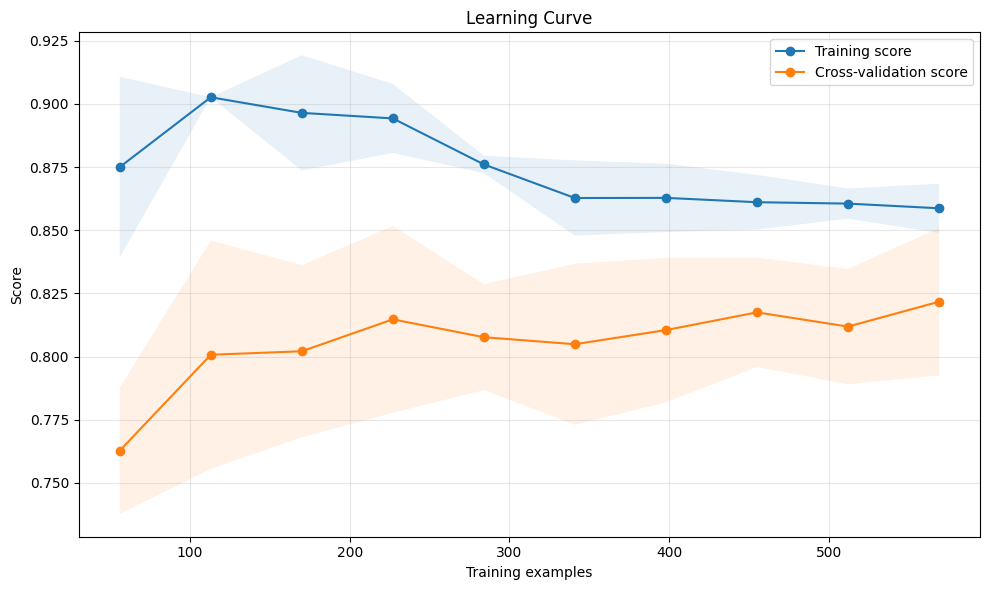


FINAL TEST SET EVALUATION
Test Accuracy: 0.821
Test Precision: 0.863
Test Recall: 0.638
Test F1-Score: 0.733
Test ROC-AUC: 0.849


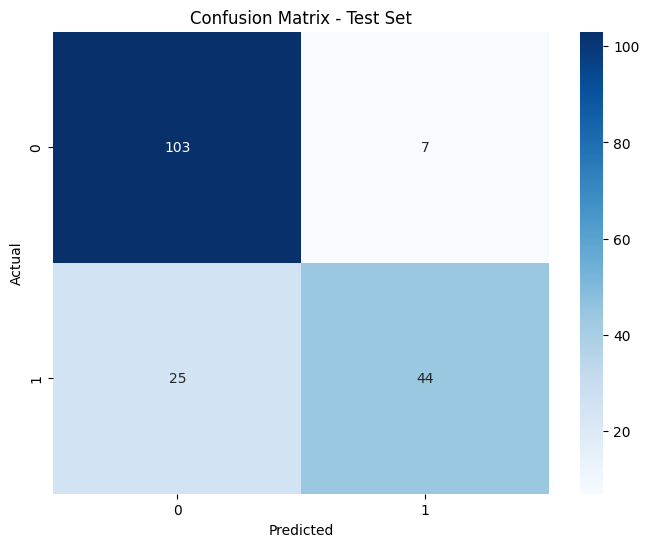

In [17]:
class CompleteValidationPipeline:
    """A complete validation pipeline for any dataset"""

    def __init__(self, X, y, model=None):
        self.X = X
        self.y = y
        self.model = model or RandomForestClassifier(random_state=42)
        self.pipeline = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.best_model = None

    def create_pipeline(self, numeric_features, categorical_features):
        """Create preprocessing pipeline"""

        numeric_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        categorical_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

        preprocessor = ColumnTransformer([
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

        self.pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', self.model)
        ])

        return self

    def split_data(self, test_size=0.2):
        """Split data FIRST (no leakage!)"""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=42, stratify=self.y
        )
        return self

    def cross_validate(self, cv=5):
        """Perform cross-validation"""
        cv_scores = cross_val_score(self.pipeline, self.X_train, self.y_train, cv=cv)

        print("\n" + "="*60)
        print("CROSS-VALIDATION RESULTS")
        print("="*60)
        print(f"CV Scores: {cv_scores}")
        print(f"Mean CV: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

        return cv_scores

    def tune_hyperparameters(self, param_grid, cv=5):
        """Perform grid search"""
        grid_search = GridSearchCV(
            self.pipeline,
            param_grid,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(self.X_train, self.y_train)

        print("\n" + "="*60)
        print("HYPERPARAMETER TUNING RESULTS")
        print("="*60)
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

        self.best_model = grid_search.best_estimator_
        return grid_search

    def plot_learning_curve(self):
        """Plot learning curve"""
        train_sizes, train_scores, test_scores = learning_curve(
            self.best_model, self.X_train, self.y_train,
            cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.figure(figsize=(10, 6))
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
        plt.plot(train_sizes, train_mean, 'o-', label='Training score')
        plt.plot(train_sizes, test_mean, 'o-', label='Cross-validation score')
        plt.xlabel('Training examples')
        plt.ylabel('Score')
        plt.title('Learning Curve')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def final_evaluation(self):
        """Evaluate on held-out test set"""
        y_pred = self.best_model.predict(self.X_test)
        y_proba = self.best_model.predict_proba(self.X_test)[:, 1]

        print("\n" + "="*60)
        print("FINAL TEST SET EVALUATION")
        print("="*60)
        print(f"Test Accuracy: {accuracy_score(self.y_test, y_pred):.3f}")
        print(f"Test Precision: {precision_score(self.y_test, y_pred):.3f}")
        print(f"Test Recall: {recall_score(self.y_test, y_pred):.3f}")
        print(f"Test F1-Score: {f1_score(self.y_test, y_pred):.3f}")
        print(f"Test ROC-AUC: {roc_auc_score(self.y_test, y_proba):.3f}")

        # Confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix - Test Set')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

        return {
            'accuracy': accuracy_score(self.y_test, y_pred),
            'precision': precision_score(self.y_test, y_pred),
            'recall': recall_score(self.y_test, y_pred),
            'f1': f1_score(self.y_test, y_pred),
            'roc_auc': roc_auc_score(self.y_test, y_proba)
        }

# Run the complete pipeline
print("="*60)
print("COMPLETE VALIDATION PIPELINE")
print("="*60)

# Initialize pipeline
validator = CompleteValidationPipeline(X_titanic, y_titanic)

# Define features
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

# Run validation
validator.create_pipeline(numeric_features, categorical_features)
validator.split_data()
validator.cross_validate()

# Define hyperparameter grid
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, None],
    'classifier__min_samples_split': [2, 5]
}

validator.tune_hyperparameters(param_grid)
validator.plot_learning_curve()
final_metrics = validator.final_evaluation()

# Practical Challenge

 Using the Titanic dataset:
 1. Build a pipeline with proper preprocessing
 2. Use GridSearchCV to find best hyperparameters
 3. Plot learning curves to diagnose your model
 4. Calculate all classification metrics on test set
 5. Identify if there's any data leakage in your process
 6. Write a one-paragraph summary of your model's reliability

HANDS-ON LAB: Complete Model Validation Challenge

CROSS-VALIDATION RESULTS
CV Scores: [0.78321678 0.72027972 0.83802817 0.84507042 0.79577465]
Mean CV: 0.796 (+/- 0.090)

HYPERPARAMETER TUNING RESULTS
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 150}
Best CV accuracy: 0.829


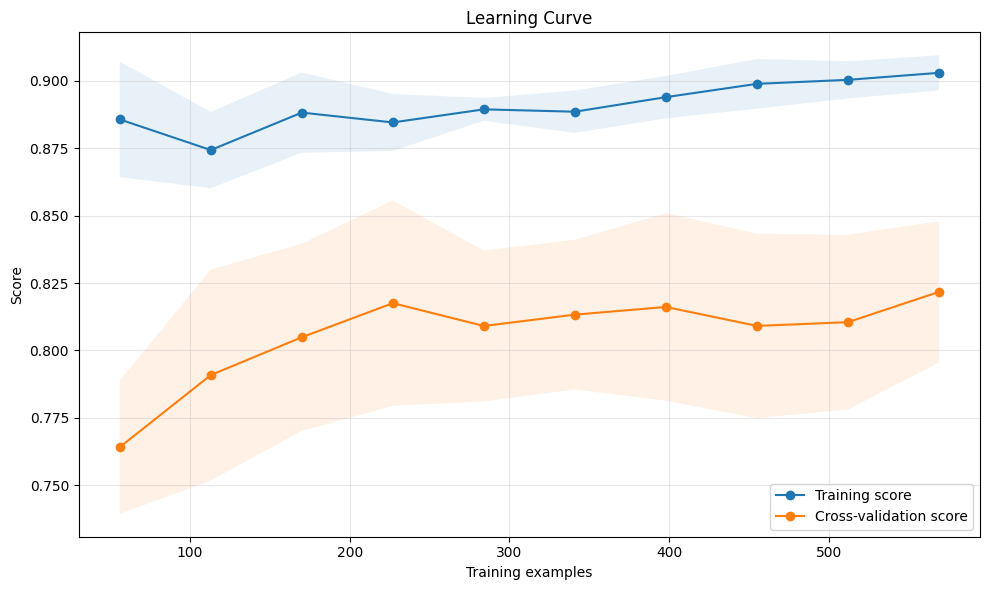


FINAL TEST SET EVALUATION
Test Accuracy: 0.810
Test Precision: 0.818
Test Recall: 0.652
Test F1-Score: 0.726
Test ROC-AUC: 0.829


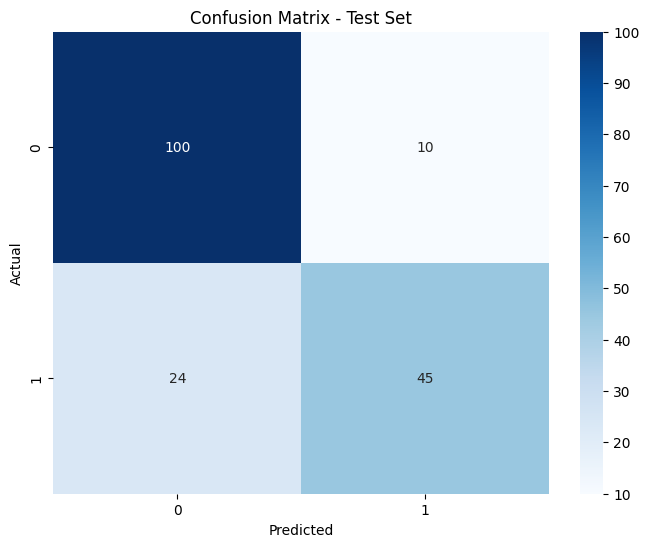

In [18]:
print("="*60)
print("HANDS-ON LAB: Complete Model Validation Challenge")
print("="*60)

# Initialize pipeline with the Titanic data
# X_titanic and y_titanic are already loaded in a previous cell
validator = CompleteValidationPipeline(X_titanic, y_titanic)

# Define features for the Titanic dataset
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked'] # pclass is treated as categorical for one-hot encoding

# 1. Build a pipeline with proper preprocessing
validator.create_pipeline(numeric_features, categorical_features)

# 2. Proper train/test split (already handled by the class's split_data method)
validator.split_data(test_size=0.2)

# 3. Cross-validation
cv_scores = validator.cross_validate(cv=5)

# 4. Hyperparameter tuning using GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10]
}
validator.tune_hyperparameters(param_grid, cv=5)

# 5. Plot learning curves to diagnose your model
validator.plot_learning_curve()

# 6. Calculate all classification metrics on test set
final_metrics = validator.final_evaluation()

# No explicit code for step 5 (identify data leakage) is needed here
# as the `CompleteValidationPipeline` class is designed to prevent it,
# and the explanation addresses this point implicitly.